In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [7]:
columns_to_check = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in columns_to_check:
    zero_count = (df[col] == 0).sum()
    zero_percentage = 100 * zero_count / len(df)
    print(f"{col}: {zero_count} - %{zero_percentage:.2f}")

Glucose: 5 - %0.65
BloodPressure: 35 - %4.56
SkinThickness: 227 - %29.56
Insulin: 374 - %48.70
BMI: 11 - %1.43


In [8]:
# Bu değerlerin NaN olma ihtimali var. NaN değeleri 0 ile doldurmuş olabilirler. 

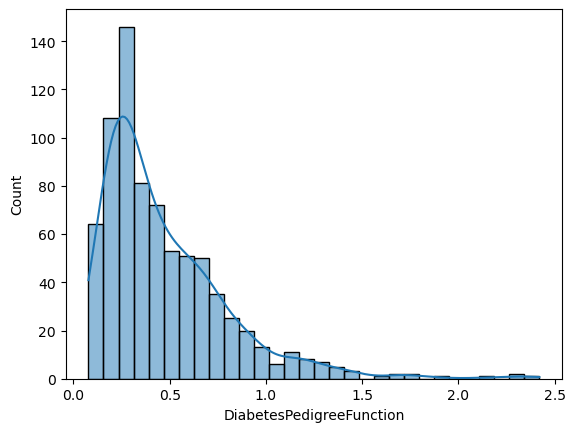

In [9]:
# Diyabet olmaya genetik yatkınlık dağılımı
sns.histplot(df["DiabetesPedigreeFunction"], bins=30,kde=True)
plt.show()

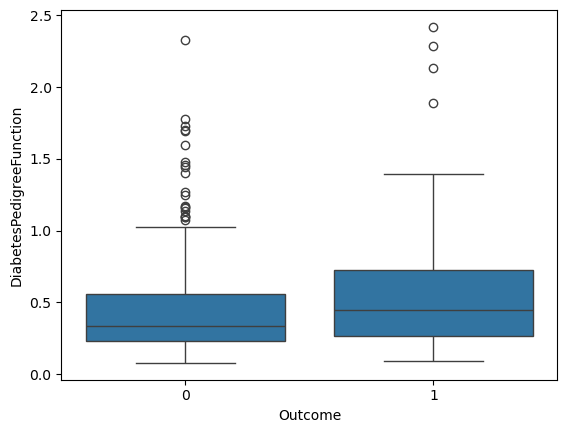

In [10]:
sns.boxplot(x='Outcome', y='DiabetesPedigreeFunction', data=df)
plt.show()

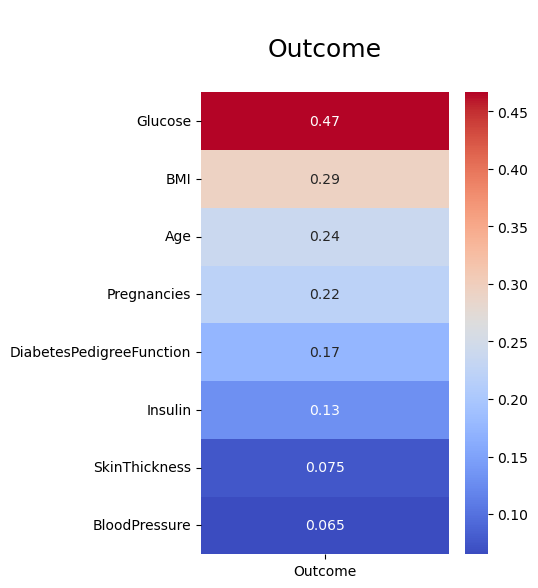

In [11]:
def corr_to_target(dataframe, target, title=None, file=None):
    plt.figure(figsize=(4,6))
    sns.heatmap(dataframe.corr()[[target]].sort_values(target,
                                                        ascending=False)[1:],
                                                        annot=True,
                                                        cmap='coolwarm')
    
    plt.title(f'\n{title}\n', fontsize=18)   
    plt.show();
    
    return

corr_to_target(df, "Outcome", title="Outcome")

In [12]:
X = df.drop('Outcome', axis=1)
y = df["Outcome"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [14]:
# 0 olan değerleri medyan ile dolduruyoruz.
columns_to_fill = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

medians = {}
for col in columns_to_fill:
    median_value = X_train[X_train[col] != 0][col].median()
    medians[col] = median_value
    X_train[col] = X_train[col].replace(0, median_value)

for col in columns_to_fill:
    X_test[col] = X_test[col].replace(0, medians[col])

In [15]:
X_train.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,3.907166,121.560261,72.612378,29.040717,142.477199,32.448208,0.469948,33.285016
std,3.385438,29.974412,12.165642,8.312217,80.879330,6.862948,0.328516,11.678337
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.084000,21.000000
25%,1.000000,100.000000,64.000000,25.000000,125.000000,27.600000,0.238250,24.000000
50%,3.000000,117.000000,72.000000,29.000000,129.500000,32.300000,0.370500,29.000000
75%,6.000000,139.750000,80.000000,32.000000,130.000000,36.500000,0.630750,40.000000
max,17.000000,199.000000,122.000000,63.000000,680.000000,67.100000,2.420000,81.000000


In [16]:
# Ağaç algoritmalarında scaling yapmaya gerek yok, çook önemli değil, kullansak da çok fark yaratmaz

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [18]:
ada = AdaBoostClassifier()
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)

In [19]:
print("Accuracy: ", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy:  0.7532467532467533
[[87 21]
 [17 29]]
              precision    recall  f1-score   support

           0       0.84      0.81      0.82       108
           1       0.58      0.63      0.60        46

    accuracy                           0.75       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.76      0.75      0.76       154



In [20]:
# hyperparameter tuning

In [21]:
from sklearn.model_selection import GridSearchCV

In [22]:
adaboost_param = {
    "n_estimators": [50,100,150,200],
    "learning_rate": [0.01,0.1,1]
}

In [23]:
grid = GridSearchCV(estimator=AdaBoostClassifier(), param_grid=adaboost_param, cv=5, verbose=1, n_jobs=-1)

In [24]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=AdaBoostClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 1],
                         'n_estimators': [50, 100, 150, 200]},
             verbose=1)

In [25]:
grid.best_params_

{'learning_rate': 1, 'n_estimators': 150}

In [26]:
ada = AdaBoostClassifier(learning_rate=1, n_estimators=150)
ada.fit(X_train, y_train)

AdaBoostClassifier(learning_rate=1, n_estimators=150)

In [27]:
y_pred = ada.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy:  0.7597402597402597
[[87 21]
 [16 30]]
              precision    recall  f1-score   support

           0       0.84      0.81      0.82       108
           1       0.59      0.65      0.62        46

    accuracy                           0.76       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.77      0.76      0.76       154



# Ödev - Diğer Sınıflandırma Algoritmaları ile Karşılaştırma
### Logistic Regresyon
### Support Vector Classifier (SVC)
### Naive Bayes
### KNN
### Random Forest Classifier

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [29]:
def calculate_model_metrics(true, predicted):
    accuracy = accuracy_score(true, predicted)
    c_matrix = confusion_matrix(true, predicted)
    c_report = classification_report(true, predicted)

    return accuracy, c_matrix, c_report

In [30]:
models = {
    "Logistic Regression": LogisticRegression(),
    "SVC": SVC(),
    "Naive Bayes": GaussianNB(),
    "K-Neighbors Classifier": KNeighborsClassifier(),
    "Random Forest Classifier": RandomForestClassifier()
}

In [31]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    model_acc, model_matrix, model_report = calculate_model_metrics(y_test, y_pred)

    print("***",list(models.values())[i],"***\n")

    print(f"Accuracy: {model_acc:.3f}")
    print("Confusion Matrix: \n", model_matrix)
    print("Classification Report:\n ", model_report)

    print("------------------------")
    print("\n")

*** LogisticRegression() ***

Accuracy: 0.753
Confusion Matrix: 
 [[89 19]
 [19 27]]
Classification Report:
                precision    recall  f1-score   support

           0       0.82      0.82      0.82       108
           1       0.59      0.59      0.59        46

    accuracy                           0.75       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.75      0.75      0.75       154

------------------------


*** SVC() ***

Accuracy: 0.727
Confusion Matrix: 
 [[87 21]
 [21 25]]
Classification Report:
                precision    recall  f1-score   support

           0       0.81      0.81      0.81       108
           1       0.54      0.54      0.54        46

    accuracy                           0.73       154
   macro avg       0.67      0.67      0.67       154
weighted avg       0.73      0.73      0.73       154

------------------------


*** GaussianNB() ***

Accuracy: 0.721
Confusion Matrix: 
 [[85 23]
 [20 26]]
Classifica

In [32]:
#hyperparameter tuning
svc_params = {
    "C": [0.001, 0.1,1,10,50,100],
    "kernel": ["rbf"],
    "gamma": ["scale","auto"]
}
knn_params = {
    "n_neighbors":[5,10,15,20,25,30]
}
rfc_params = {
    "max_depth": [5, 8, 15, 10, None],
    "max_features": [5, 7, "sqrt", "log2"],
    "min_samples_split": [2, 8, 15, 20],
    "n_estimators": [100, 200, 300, 500]
}

In [33]:
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings("ignore")

randomcv_models = [
    ("SVC", SVC(), svc_params),
    ("KNN", KNeighborsClassifier(), knn_params),
    ("RF", RandomForestClassifier(), rfc_params)
]

for name, model, params in randomcv_models:
    #print(name)
    print(model)
    print(params)
    print()

SVC()
{'C': [0.001, 0.1, 1, 10, 50, 100], 'kernel': ['rbf'], 'gamma': ['scale', 'auto']}

KNeighborsClassifier()
{'n_neighbors': [5, 10, 15, 20, 25, 30]}

RandomForestClassifier()
{'max_depth': [5, 8, 15, 10, None], 'max_features': [5, 7, 'sqrt', 'log2'], 'min_samples_split': [2, 8, 15, 20], 'n_estimators': [100, 200, 300, 500]}



In [39]:
for name, model, params in randomcv_models:
    randomcv = RandomizedSearchCV(estimator=model, param_distributions=params, cv=3, n_jobs=-1)
    randomcv.fit(X_train, y_train)

    print("best params for :", name, randomcv.best_params_)

best params for : SVC {'kernel': 'rbf', 'gamma': 'scale', 'C': 1}
best params for : KNN {'n_neighbors': 20}
best params for : RF {'n_estimators': 100, 'min_samples_split': 20, 'max_features': 'log2', 'max_depth': 15}


In [40]:
models = {
    "Support Vector Classifier": SVC(kernel="rbf", gamma="scale", C=1),
    "K-Neighbors Classifier": KNeighborsClassifier(n_neighbors=20),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=100,
                                                    min_samples_split=20,
                                                    max_features="log2",
                                                    max_depth=15)
}

In [41]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    model_acc, model_matrix, model_report = calculate_model_metrics(y_test, y_pred)

    print("***",list(models.values())[i],"***\n")

    print(f"Accuracy: {model_acc:.3f}")
    print("Confusion Matrix: \n", model_matrix)
    print("Classification Report:\n ", model_report)

    print("------------------------")
    print("\n")

*** SVC(C=1) ***

Accuracy: 0.727
Confusion Matrix: 
 [[87 21]
 [21 25]]
Classification Report:
                precision    recall  f1-score   support

           0       0.81      0.81      0.81       108
           1       0.54      0.54      0.54        46

    accuracy                           0.73       154
   macro avg       0.67      0.67      0.67       154
weighted avg       0.73      0.73      0.73       154

------------------------


*** KNeighborsClassifier(n_neighbors=20) ***

Accuracy: 0.727
Confusion Matrix: 
 [[90 18]
 [24 22]]
Classification Report:
                precision    recall  f1-score   support

           0       0.79      0.83      0.81       108
           1       0.55      0.48      0.51        46

    accuracy                           0.73       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.72      0.73      0.72       154

------------------------


*** RandomForestClassifier(max_depth=15, max_features='log2', min_sa

# Sonuç
### Logistic Regresyon --> Accuracy = 0.75
### SVC --> Accuracy = 0.73 - (After Hyperparameter tuning = 0.73)
### Gaussian Naive Bayes --> Accuracy = 0.72
### KNN --> Accuracy: 0.69 - (After Hyperparameter tuning = 0.73)
### Random Forest --> Accuracy: 0.73 - (After Hyperparameter tuning = 0.73)